# Assignment 11: Iris Dataset - Cleaning, Summary Statistics and Plots

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))
df = df.drop(columns="target")
feature_cols = [c for c in df.columns if c != "species"]
print(df.head())
print(df.shape)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
(150, 5)


In [2]:
# introduce missing values to simulate messy real world data, then clean it
def introduce_missing(df, feature_cols, fraction, rng):
    dirty = df.copy()
    mask = rng.random((len(dirty), len(feature_cols))) < fraction
    values = dirty[feature_cols].to_numpy(dtype=float, copy=True)
    values[mask] = np.nan
    dirty[feature_cols] = values
    return dirty


def clean_missing(df, feature_cols):
    result = df.copy()
    result[feature_cols] = result[feature_cols].fillna(result[feature_cols].mean())
    return result


rng = np.random.default_rng(42)
df_dirty = introduce_missing(df, feature_cols, 0.05, rng)
df_clean = clean_missing(df_dirty, feature_cols)
print("missing before cleaning:", df_dirty[feature_cols].isna().sum().sum())
print("missing after cleaning:", df_clean[feature_cols].isna().sum().sum())

missing before cleaning: 27
missing after cleaning: 0


In [3]:
# summary statistics
print(df_clean[feature_cols].describe())
print(df_clean.groupby("species")[feature_cols].mean())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.854167          3.056849           3.648551   
std             0.821186          0.432553           1.704130   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.050000   
75%             6.400000          3.300000           5.000000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.230345  
std            0.742960  
min            0.100000  
25%            0.400000  
50%            1.300000  
75%            1.800000  
max            2.500000  
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                                                              
setosa               5.045250          3

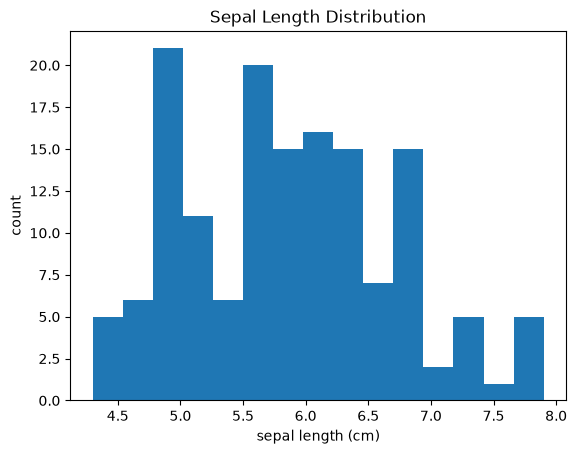

In [4]:
# plot 1: histogram of sepal length
fig1, ax1 = plt.subplots()
ax1.hist(df_clean["sepal length (cm)"], bins=15)
ax1.set_title("Sepal Length Distribution")
ax1.set_xlabel("sepal length (cm)")
ax1.set_ylabel("count")
assert len(ax1.patches) > 0
plt.show()

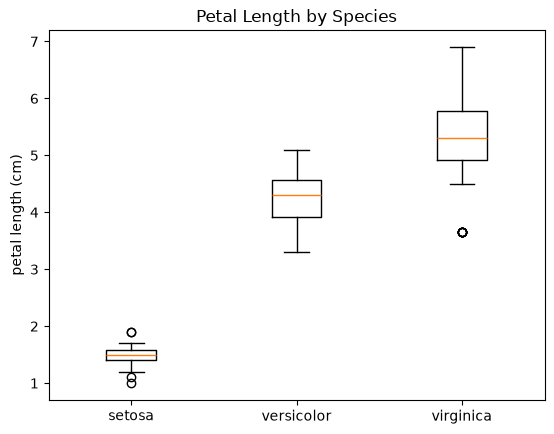

In [5]:
# plot 2: boxplot of petal length grouped by species
fig2, ax2 = plt.subplots()
groups = [df_clean.loc[df_clean["species"] == s, "petal length (cm)"] for s in iris.target_names]
bp = ax2.boxplot(groups, tick_labels=list(iris.target_names))
ax2.set_title("Petal Length by Species")
ax2.set_ylabel("petal length (cm)")
assert len(bp["boxes"]) == 3
plt.show()

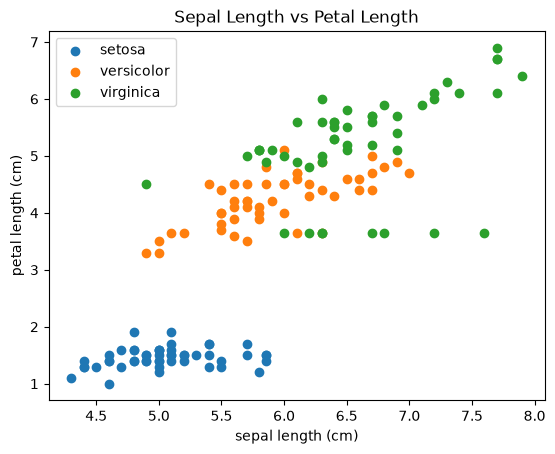

In [6]:
# plot 3: scatter of sepal length vs petal length colored by species
fig3, ax3 = plt.subplots()
colors = {"setosa": "tab:blue", "versicolor": "tab:orange", "virginica": "tab:green"}
for species, group in df_clean.groupby("species"):
    ax3.scatter(group["sepal length (cm)"], group["petal length (cm)"], label=species, color=colors[species])
ax3.set_xlabel("sepal length (cm)")
ax3.set_ylabel("petal length (cm)")
ax3.set_title("Sepal Length vs Petal Length")
ax3.legend()
assert len(ax3.collections) == 3
plt.show()

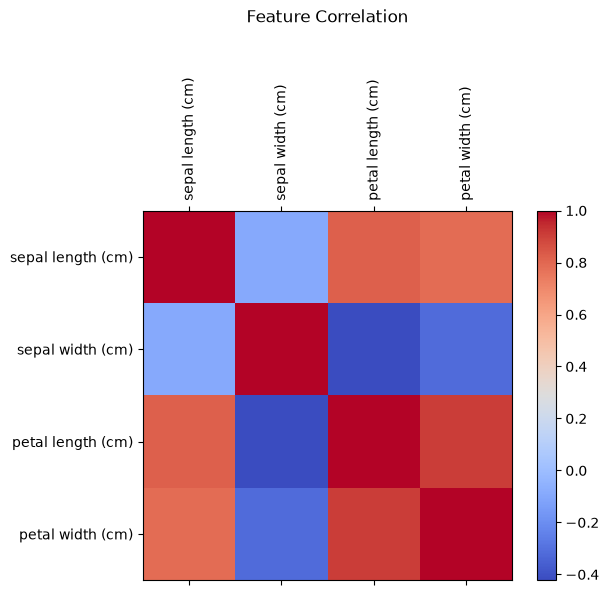

In [7]:
# plot 4: correlation heatmap of the numeric features
fig4, ax4 = plt.subplots()
corr = df_clean[feature_cols].corr()
im = ax4.matshow(corr, cmap="coolwarm")
ax4.set_xticks(range(len(feature_cols)))
ax4.set_yticks(range(len(feature_cols)))
ax4.set_xticklabels(feature_cols, rotation=90)
ax4.set_yticklabels(feature_cols)
fig4.colorbar(im)
ax4.set_title("Feature Correlation", pad=40)
assert len(ax4.images) == 1
plt.show()

In [8]:
# edge and negative case checks, kept separate from the analysis above
assert df_dirty[feature_cols].isna().sum().sum() > 0
assert df_clean[feature_cols].isna().sum().sum() == 0
assert df_clean.shape == df.shape
assert set(df_clean["species"].unique()) == {"setosa", "versicolor", "virginica"}
assert df_clean["species"].equals(df_dirty["species"])

no_missing = clean_missing(df, feature_cols)
assert no_missing[feature_cols].equals(df[feature_cols])

tiny = pd.DataFrame({"a": [1.0, np.nan, 3.0]})
tiny_clean = clean_missing(tiny, ["a"])
assert tiny_clean["a"].isna().sum() == 0
assert tiny_clean.loc[1, "a"] == 2.0

print("all tests passed")

all tests passed
